# Systems Conference Topic Explorer

Six interactive visualisations of how systems research topics evolved from 2012 to 2026.

**Cell 3** (clustering) calls the Anthropic API to name clusters — results are cached in `data/cluster_labels.json` after the first run. Set `ANTHROPIC_API_KEY` in your environment to enable this; otherwise placeholder labels are used.

In [1]:
from dotenv import find_dotenv, load_dotenv
load_dotenv(find_dotenv())

import sys
from pathlib import Path

repo = Path.cwd().parent
if str(repo / "src") not in sys.path:
    sys.path.insert(0, str(repo / "src"))

import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

from viz_sys_conferences.viz_data import load_editions
from viz_sys_conferences.viz_plots import (
    papers_over_time,
    session_heatmap_matrix,
    build_cluster_data,
    get_cluster_labels,
    umap_projection,
    keyword_trends,
    sunburst_data,
    conference_similarity,
    KEYWORD_GROUPS,
    N_CLUSTERS,
)

DATA_DIR = repo / "data"
editions = load_editions(DATA_DIR)
print(f"Loaded {len(editions)} editions")

Loaded 47 editions


## 1 · Papers over time

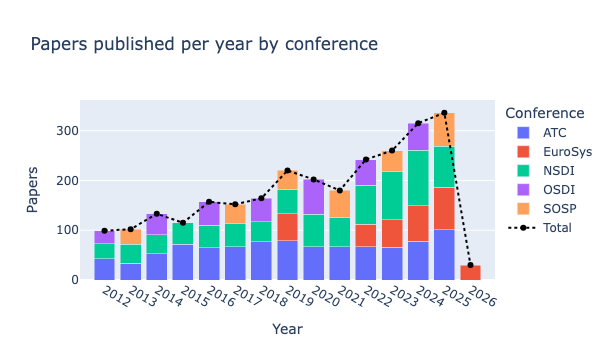

In [2]:
df = papers_over_time(editions)
totals = df.groupby("year", as_index=False)["paper_count"].sum().rename(columns={"paper_count": "total"})

fig = px.bar(
    df, x="year", y="paper_count", color="conference",
    barmode="stack",
    title="Papers published per year by conference",
    labels={"paper_count": "Papers", "year": "Year", "conference": "Conference"},
)
fig.add_scatter(
    x=totals["year"], y=totals["total"],
    mode="lines+markers", name="Total",
    line=dict(color="black", width=2, dash="dot"),
)
fig.update_layout(xaxis=dict(dtick=1), hovermode="x unified")
fig.show()

## 2 · Session topic heatmap

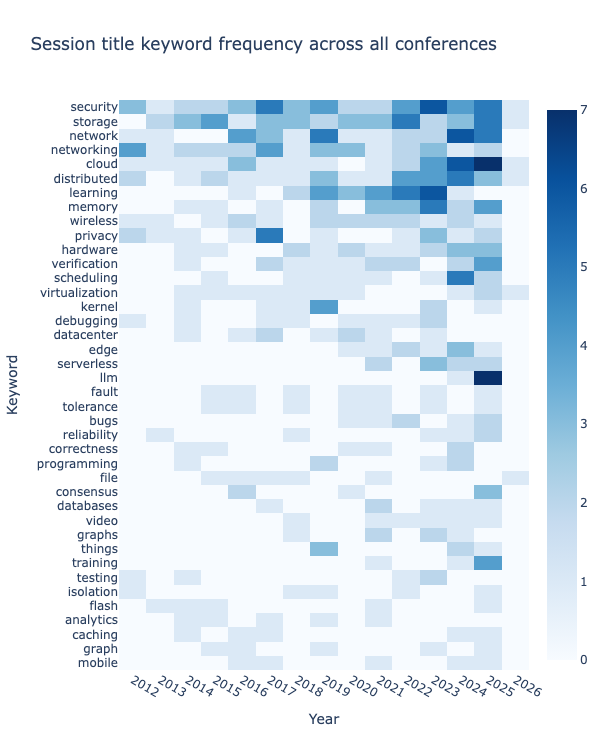

In [3]:
matrix = session_heatmap_matrix(editions, top_n=40)

fig = go.Figure(go.Heatmap(
    z=matrix.values,
    x=[str(y) for y in matrix.columns],
    y=matrix.index.tolist(),
    colorscale="Blues",
    hovertemplate="Keyword: %{y}<br>Year: %{x}<br>Count: %{z}<extra></extra>",
))
fig.update_layout(
    title="Session title keyword frequency across all conferences",
    xaxis_title="Year",
    yaxis_title="Keyword",
    height=750,
    yaxis=dict(autorange="reversed"),
)
fig.show()

## 3 · Paper clusters (LLM-labelled)

TF-IDF + KMeans clusters all paper titles into 20 groups; Claude claude-haiku-4-5 names each cluster. Results are cached in `data/cluster_labels.json` — the API is only called once.

In [4]:
titles, conf_years, cluster_ids, tfidf_matrix = build_cluster_data(editions)
print(f"{len(titles)} papers → {N_CLUSTERS} clusters")

2707 papers → 20 clusters


In [5]:
cache = DATA_DIR / "cluster_labels.json"
try:
    labels = get_cluster_labels(titles, cluster_ids, cache_path=cache)
    print("Cluster labels:", labels)
except Exception as e:
    labels = {i: f"Cluster {i}" for i in range(N_CLUSTERS)}
    raise RuntimeError(
        f"LLM cluster labelling failed: {e}\n\n"
        "Check your ANTHROPIC_API_KEY and credit balance at https://console.anthropic.com"
    ) from e

Cluster labels: {0: 'Distributed Replication Systems', 1: 'Key-Value Store Systems', 2: 'Deep Learning Systems', 3: 'Control Plane Management', 4: 'Systems Software Engineering', 5: 'System Resource Management', 6: 'Network Monitoring and Edge Computing', 7: 'Systems Design Techniques', 8: 'Large-Scale Systems Design', 9: 'Memory Management Systems', 10: 'Network Systems Research', 11: 'Conference Session Metadata', 12: 'High-Performance Systems Design', 13: 'Data Management Systems', 14: 'Cloud Storage Systems', 15: 'Systems Performance & Management', 16: 'DNN Training Optimization', 17: 'Privacy-Preserving Systems Platforms', 18: 'Low-Latency Systems Design', 19: 'Video and Data Analytics'}


Computing UMAP projection (may take ~30s)...


/Users/marcel/Developer/viz-sys-conferences/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


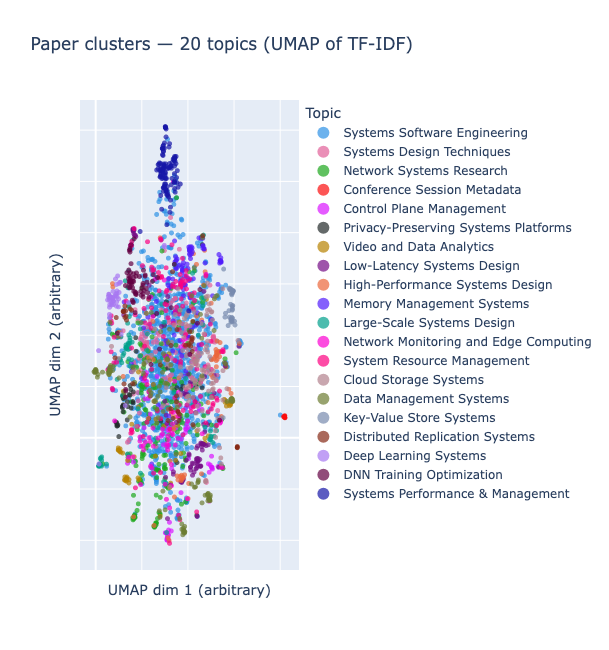

In [6]:
print("Computing UMAP projection (may take ~30s)...")
coords = umap_projection(tfidf_matrix)

plot_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "cluster": [labels[c] for c in cluster_ids],
    "title": titles,
    "edition": conf_years,
})

fig = px.scatter(
    plot_df, x="x", y="y", color="cluster",
    color_discrete_sequence=px.colors.qualitative.Dark24,
    hover_data={"title": True, "edition": True, "x": False, "y": False},
    title=f"Paper clusters — {N_CLUSTERS} topics (UMAP of TF-IDF)",
    labels={"cluster": "Topic", "x": "UMAP dim 1 (arbitrary)", "y": "UMAP dim 2 (arbitrary)"},
    opacity=0.7,
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(
    height=650,
    legend=dict(itemsizing="constant"),
    xaxis=dict(showticklabels=False),
    yaxis=dict(showticklabels=False),
)
fig.show()

## 4 · Keyword trend lines

     year                topic  frequency
0    2012              ML / AI   0.007692
1    2012                Cloud   0.092308
2    2012              Storage   0.069231
3    2012           Networking   0.153846
4    2012             Security   0.115385
..    ...                  ...        ...
145  2026  Distributed Systems   0.166667
146  2026         Verification   0.055556
147  2026          OS / Kernel   0.388889
148  2026             Hardware   0.250000
149  2026       Bugs / Testing   0.027778

[150 rows x 3 columns]


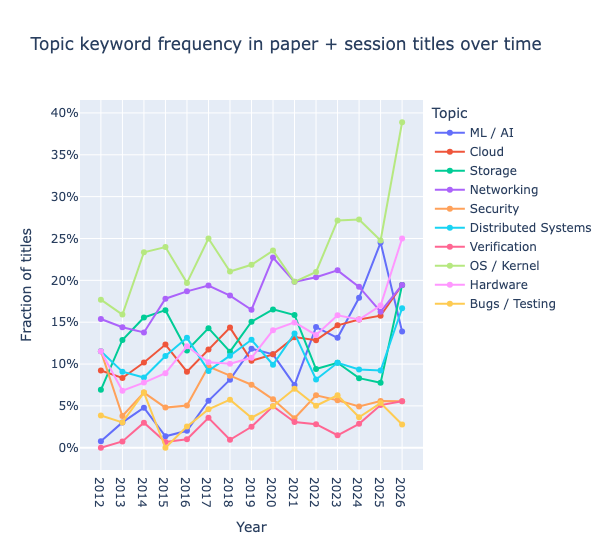

In [7]:
trends = keyword_trends(editions)
print(trends)

fig = px.line(
    trends, x="year", y="frequency", color="topic",
    markers=True,
    title="Topic keyword frequency in paper + session titles over time",
    labels={"frequency": "Fraction of titles", "year": "Year", "topic": "Topic"},
)
fig.update_layout(
    xaxis=dict(dtick=1),
    yaxis=dict(tickformat=".0%"),
    hovermode="x unified",
    height=550,
)
fig.show()

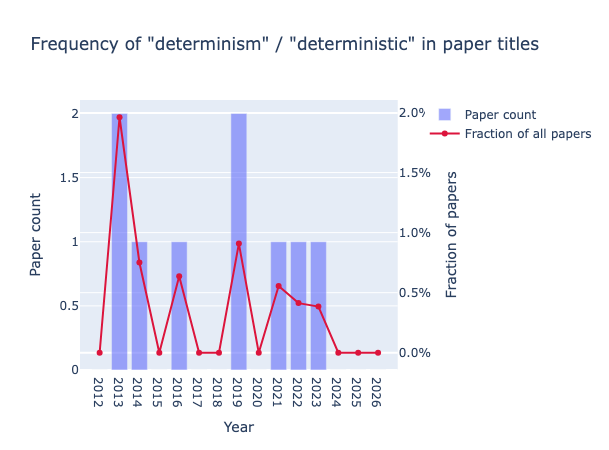

In [8]:
## Determinism / deterministic in paper titles over time

from collections import defaultdict

counts_by_year: dict[int, int] = defaultdict(int)
totals_by_year: dict[int, int] = defaultdict(int)

for e in editions:
    year = e["year"]
    for s in e["sessions"]:
        for p in s["papers"]:
            t = p["title"].lower()
            totals_by_year[year] += 1
            if "determinis" in t:  # matches determinism, deterministic, deterministically
                counts_by_year[year] += 1

years = sorted(totals_by_year)
abs_counts = [counts_by_year[y] for y in years]
rel_freq = [counts_by_year[y] / totals_by_year[y] for y in years]

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_bar(x=years, y=abs_counts, name="Paper count", opacity=0.6)
fig.add_scatter(x=years, y=rel_freq, name="Fraction of all papers",
                mode="lines+markers", line=dict(color="crimson", width=2),
                secondary_y=True)
fig.update_layout(
    title="Frequency of \"determinism\" / \"deterministic\" in paper titles",
    xaxis=dict(dtick=1, title="Year"),
    hovermode="x unified",
    height=450,
)
fig.update_yaxes(title_text="Paper count", secondary_y=False)
fig.update_yaxes(title_text="Fraction of papers", tickformat=".1%", secondary_y=True)
fig.show()


## 5 · Session sunburst

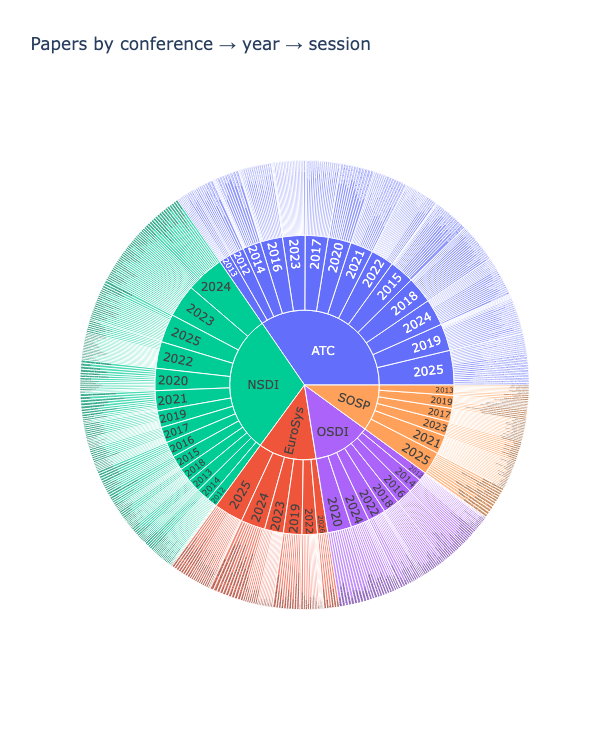

In [9]:
rows = sunburst_data(editions)
sb_df = pd.DataFrame(rows)

fig = px.sunburst(
    sb_df,
    path=["conference", "year", "session"],
    values="paper_count",
    title="Papers by conference → year → session",
    color="conference",
)
fig.update_layout(height=750)
fig.show()

## 6 · Conference topic-overlap

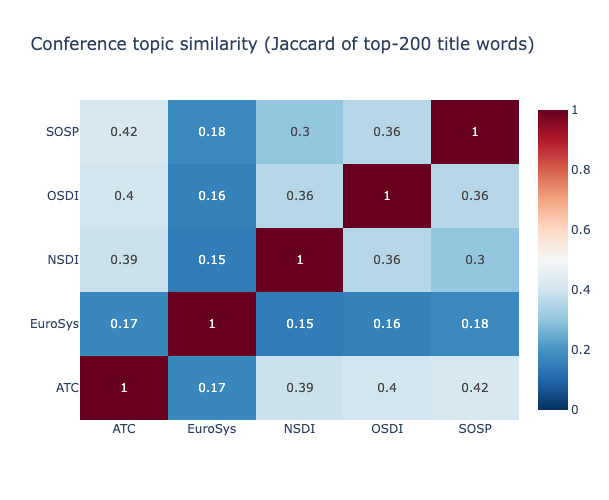

In [10]:
sim = conference_similarity(editions)
confs = sim.index.tolist()

fig = go.Figure(go.Heatmap(
    z=sim.values,
    x=confs,
    y=confs,
    colorscale="RdBu",
    reversescale=True,
    zmin=0, zmax=1,
    text=np.round(sim.values, 2),
    texttemplate="%{text}",
    hovertemplate="%{y} vs %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title="Conference topic similarity (Jaccard of top-200 title words)",
    height=500,
)
fig.show()